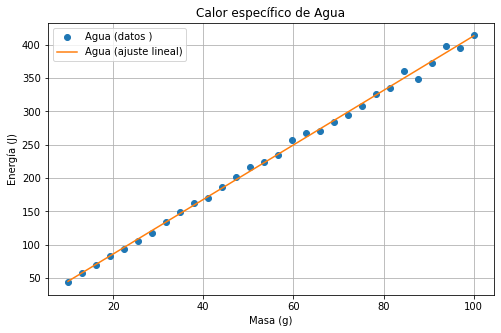


Resultados para Agua:
  Calor específico teórico: 4.186 J/g·K
  Calor específico promedio : 4.194 J/g·K
  Incertidumbre (95%): ±0.034 J/g·K
  Ajuste lineal (energía vs masa):
    Pendiente: 4.0948 J/g
    Intercepto: 4.0844 J
    R-cuadrado: 0.9979

Tabla de datos  para Agua:
    Masa (g)  Energía (J)  Calor específico  (J/g·K)
0  10.000000    43.354608                   4.335461
1  13.103448    57.385530                   4.379422
2  16.206897    69.150747                   4.266748
3  19.310345    82.379548                   4.266084
4  22.413793    93.442973                   4.168994 



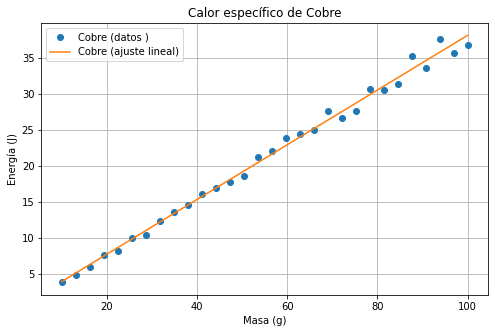


Resultados para Cobre:
  Calor específico teórico: 0.385 J/g·K
  Calor específico promedio : 0.383 J/g·K
  Incertidumbre (95%): ±0.004 J/g·K
  Ajuste lineal (energía vs masa):
    Pendiente: 0.3796 J/g
    Intercepto: 0.1706 J
    R-cuadrado: 0.9937

Tabla de datos  para Cobre:
    Masa (g)  Energía (J)  Calor específico  (J/g·K)
0  10.000000     3.845607                   0.384561
1  13.103448     4.892891                   0.373405
2  16.206897     5.987320                   0.369430
3  19.310345     7.613770                   0.394285
4  22.413793     8.276749                   0.369270 



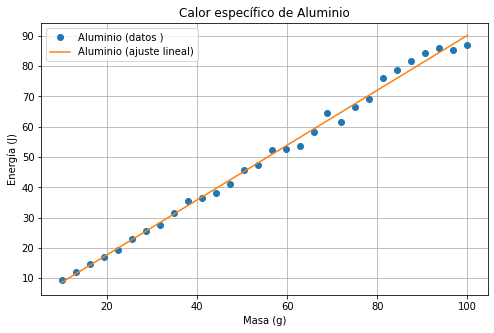


Resultados para Aluminio:
  Calor específico teórico: 0.9 J/g·K
  Calor específico promedio : 0.897 J/g·K
  Incertidumbre (95%): ±0.010 J/g·K
  Ajuste lineal (energía vs masa):
    Pendiente: 0.9058 J/g
    Intercepto: -0.4410 J
    R-cuadrado: 0.9952

Tabla de datos  para Aluminio:
    Masa (g)  Energía (J)  Calor específico  (J/g·K)
0  10.000000     9.438741                   0.943874
1  13.103448    12.061239                   0.920463
2  16.206897    14.701674                   0.907125
3  19.310345    16.900795                   0.875220
4  22.413793    19.235928                   0.858218 



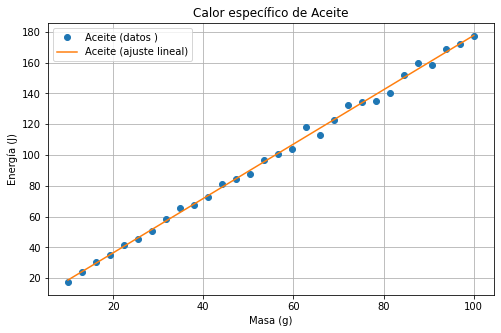


Resultados para Aceite:
  Calor específico teórico: 1.8 J/g·K
  Calor específico promedio : 1.793 J/g·K
  Incertidumbre (95%): ±0.017 J/g·K
  Ajuste lineal (energía vs masa):
    Pendiente: 1.7665 J/g
    Intercepto: 1.1087 J
    R-cuadrado: 0.9973

Tabla de datos  para Aceite:
    Masa (g)  Energía (J)  Calor específico  (J/g·K)
0  10.000000    17.213044                   1.721304
1  13.103448    24.060977                   1.836232
2  16.206897    30.567045                   1.886052
3  19.310345    34.840388                   1.804234
4  22.413793    41.418255                   1.847891 



In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import linregress

# Constantes teóricas para los calores específicos (J/g·K)
constantes = {
    "Agua": 4.186,  # Calor específico del agua
    "Cobre": 0.385, # Calor específico del cobre
    "Aluminio": 0.900, # Calor específico del aluminio
    "Aceite": 1.800  # Calor específico de un aceite típico
}

# Función para simular mediciones con incertidumbre
def simular_mediciones(calor_teorico, num_mediciones, incertidumbre_relativa):
    mediciones = calor_teorico * (1 + np.random.uniform(-incertidumbre_relativa, incertidumbre_relativa, num_mediciones))
    return mediciones

# Generar datos 
num_mediciones = 30
incertidumbre_relativa = 0.05  # 5% de incertidumbre relativa

data = {}
for material, calor in constantes.items():
    data[material] = simular_mediciones(calor, num_mediciones, incertidumbre_relativa)

# Análisis de datos y presentación en tabla
tablas = {}
for material, mediciones in data.items():
    promedio = np.mean(mediciones)
    desviacion_estandar = np.std(mediciones)
    incertidumbre = desviacion_estandar / np.sqrt(num_mediciones)

    # Simulamos un experimento de transferencia de calor
    masas = np.linspace(10, 100, num_mediciones)  # Masas de 10 a 100 g
    energias = masas * mediciones  # Q = m*c*T (T constante)

    # Ajuste lineal: Energía vs Masa
    slope, intercept, r_value, p_value, std_err = linregress(masas, energias)

    # Crear tabla con los datos 
    tabla = pd.DataFrame({
        "Masa (g)": masas,
        "Energía (J)": energias,
        "Calor específico  (J/g·K)": mediciones
    })
    tablas[material] = tabla

    # Graficar ajuste lineal
    plt.figure(figsize=(8, 5))
    plt.plot(masas, energias, 'o', label=f"{material} (datos )")
    plt.plot(masas, slope * masas + intercept, '-', label=f"{material} (ajuste lineal)")
    plt.xlabel("Masa (g)")
    plt.ylabel("Energía (J)")
    plt.title(f"Calor específico de {material}")
    plt.legend()
    plt.grid()
    plt.show()

    # Imprimir resultados
    print(f"\nResultados para {material}:")
    print(f"  Calor específico teórico: {constantes[material]} J/g·K")
    print(f"  Calor específico promedio : {promedio:.3f} J/g·K")
    print(f"  Incertidumbre (95%): ±{2 * incertidumbre:.3f} J/g·K")
    print(f"  Ajuste lineal (energía vs masa):")
    print(f"    Pendiente: {slope:.4f} J/g")
    print(f"    Intercepto: {intercept:.4f} J")
    print(f"    R-cuadrado: {r_value**2:.4f}")
    print(f"\nTabla de datos  para {material}:")
    print(tabla.head(), "\n")
